# exp06 — Baseline rujukan di bawah protokol terpadu

## Mengapa eksperimen ini menentukan segalanya

Naskah lama mengklaim keunggulan dengan mengadu `RMSE 577,63` melawan CNN 775,28,
MLP 825,32, Transformer 881,28, dan seterusnya. Klaim itu tidak sah — bukan hanya
karena 577,63 berasal dari konfigurasi `V0` yang bocor, tetapi karena **angka-angka
rujukan itu pun direproduksi lewat pipeline yang sama**: pipeline dengan kebocoran
`Customers` dan pembagian data berbasis indeks.

Model Anda sendiri memburuk dari 577,63 menjadi 1004,69 (**+74%**) begitu protokolnya
dibetulkan, lalu turun lagi ke 945,42 setelah exp05d. Tidak ada alasan baseline deep
learning kebal terhadap koreksi yang sama, karena mereka melewati pipeline yang sama.

Eksperimen ini menjalankan ulang seluruh baseline itu **di bawah kontrak yang identik
dengan AR-LRX**, sehingga satu tabel perbandingan yang sah akhirnya dapat dibuat.

## Apa artinya "identik"

Setiap model menerima matriks fitur yang sama persis (`V3_sales_lagged`, 17 fitur),
pembagian kronologis yang sama (589.839 / 119.588 / 129.333), seed yang sama,
penyetelan **hanya** pada fold validation, refit pada train+val, test disentuh
**satu kali**, dan evaluasi dikembalikan ke skala asli lewat `expm1`.

**Representasi model berurut.** CNN, RNN, LSTM, GRU, dan Transformer menerima matriks
yang sama, dibentuk ulang menjadi `(n, p, 1)`. Ini bukan kompromi yang merugikan
mereka: informasi temporalnya memang sudah berada di dalam fitur (`lag_1` penjualan,
rata-rata bergulir). Membangun jendela waktu terpisah **hanya** untuk model berurut
justru akan memberi mereka informasi yang tidak dimiliki pembanding.

**Anggaran pelatihan.** Jumlah epoch ditetapkan, bukan early stopping, supaya fase
penyetelan dan fase refit memakai anggaran identik — syarat agar refit pada train+val
sah tanpa menyentuh test.

**Yang tidak disertakan, dan mengapa.** TS-XGBoost dan TS-LGBM (Zeng et al.) runtuh
menjadi model pohon biasa di bawah protokol ini, karena rekayasa fitur temporalnya
kini menjadi milik bersama semua model — memasukkannya berarti menduplikasi XGBoost.
ARIMA dan Prophet adalah model deret tunggal, sedangkan Rossmann adalah panel 1.115
toko; menjalankannya per toko bukan lagi baseline yang sama.

## Prasyarat

`src/experiments/baselines.py` (berkas baru) di folder `src/experiments/`, lalu
**Restart Kernel**. Paket yang dibutuhkan sudah ada di `pyproject.toml`:
`keras`, `tensorflow`, `lightgbm`.

In [1]:
import sys, os, json, time, warnings
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
warnings.filterwarnings("ignore")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.experiments import protocol as P
from src.experiments import baselines as B

P.set_global_seed()
EXPERIMENT = "exp06_rossmann_baselines_unified"
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 60)
print("Lingkungan:", P.environment_stamp())
try:
    import keras, tensorflow as tf, lightgbm
    print("keras", keras.__version__, "| tensorflow", tf.__version__,
          "| lightgbm", lightgbm.__version__)
    print("GPU terdeteksi:", tf.config.list_physical_devices("GPU"))
except Exception as e:
    print("PERIKSA INSTALASI:", e)

Lingkungan: {'python': '3.10.11', 'platform': 'Windows-10-10.0.22621-SP0', 'numpy': '2.2.6', 'pandas': '2.3.3', 'seed': '42', 'sklearn': '1.7.2', 'xgboost': '3.2.0', 'statsmodels': '0.14.6'}
keras 3.12.4 | tensorflow 2.21.0 | lightgbm 4.7.0
GPU terdeteksi: []


## 1. Uji-cepat arsitektur — 30 detik, sebelum membuang berjam-jam

Sel ini membangun, melatih satu epoch, dan memprediksi dengan **setiap** arsitektur
pada 256 baris sintetis. Bila ada galat API Keras, ia muncul di sini, bukan setelah
dua jam pelatihan. Angkanya tidak berarti apa-apa.

In [2]:
t0 = time.time()
B.smoke_test()
print(f"\nUji-cepat selesai dalam {time.time()-t0:.1f} detik.")

  mlp          OK  (contoh prediksi +0.0401)
  cnn          OK  (contoh prediksi +0.1676)
  rnn          OK  (contoh prediksi +0.2441)
  lstm         OK  (contoh prediksi -0.0138)
  gru          OK  (contoh prediksi -0.0013)
  transformer  OK  (contoh prediksi -0.1247)
  lightgbm     OK  (contoh prediksi +0.5183)
  xgboost      OK  (contoh prediksi +0.5897)
Seluruh arsitektur dapat dibangun, dilatih, dan memprediksi.

Uji-cepat selesai dalam 19.1 detik.


## 2. Data — hanya varian V3

`V3_sales_lagged` dipilih sebagai varian tunggal karena ia yang paling dekat dengan
keadaan yang diasumsikan naskah-naskah rujukan (penjualan historis tersedia sebagai
prediktor) dan paling kaya informasi. Satu varian sudah cukup untuk tabel utama.

In [3]:
frame = P.build_rossmann_frame("../data/raw/rossmann/train.csv",
                               "../data/raw/rossmann/store.csv")
VARIANT = "V3_sales_lagged"

QUICK_RUN = False   # True = 80 toko + 2 epoch, untuk memastikan pipeline jalan
EPOCHS = 3 if QUICK_RUN else 12

if QUICK_RUN:
    keep = np.sort(frame["Store"].unique())[:80]
    frame = frame[frame["Store"].isin(keep)].reset_index(drop=True)

d = P.build_rossmann_dataset(frame, VARIANT, target="log1p")
print("Bentuk kerangka:", frame.shape, "| toko:", frame["Store"].nunique())
print(pd.Series(d.describe())[["feature_set", "n_features", "n_train", "n_val",
                               "n_test", "train_end", "val_end", "test_end"]].to_string())
print(f"\nEpoch per pelatihan: {EPOCHS} | batch: {B.BATCH_SIZE}")

Bentuk kerangka: (838760, 23) | toko: 1115
feature_set    V3_sales_lagged
n_features                  17
n_train                 589839
n_val                   119588
n_test                  129333
train_end           2014-10-23
val_end             2015-03-12
test_end            2015-07-31

Epoch per pelatihan: 12 | batch: 2048


## 3. Menjalankan baseline neural

Enam arsitektur, masing-masing dengan grid dua konfigurasi (lebar lapisan 32 vs 64)
yang dipilih dari RMSE validation, lalu di-refit pada train+val. Penskalaan
`standard` di-fit **hanya** pada blok pelatihan aktif (kontrak C6) — model neural
memerlukannya, model pohon tidak.

Sel ini bagian paling lama. Setiap model mencetak waktunya sendiri.

In [4]:
rows = []
for label, kind, grid in B.NEURAL_MODELS:
    t0 = time.time()
    fp = B.make_keras_fp(kind, epochs=EPOCHS)
    r = P.run_model(label, fp, d, grid, scaler_kind="standard",
                    inverse_transform=np.expm1)
    rows.append(r)
    print(f"  {label:30s} RMSE(asli) {r['orig_RMSE']:9.2f}  "
          f"R2 {r['orig_R2']:.4f}  [{time.time()-t0:6.1f} d]", flush=True)

  MLP (Diamantini)               RMSE(asli)   1764.32  R2 0.6811  [  57.7 d]
  CNN (Diamantini)               RMSE(asli)   1970.26  R2 0.6023  [ 227.9 d]
  RNN (Diamantini)               RMSE(asli)   1424.57  R2 0.7921  [ 275.0 d]
  LSTM (Diamantini / Qureshi)    RMSE(asli)   1757.61  R2 0.6835  [ 929.4 d]
  GRU (Qureshi)                  RMSE(asli)   1398.12  R2 0.7997  [1064.4 d]
  Transformer (Diamantini)       RMSE(asli)   2738.56  R2 0.2316  [3087.6 d]


## 4. Baseline pohon

LightGBM (Zeng et al.) dan XGBoost dengan wilayah hyperparameter yang dilaporkan
Zhao et al. Keduanya tanpa penskalaan, seperti model pohon pada umumnya.

In [5]:
for label, fp, grid in [
        ("LightGBM (Zeng)", B.fp_lightgbm, B.GRID_LIGHTGBM),
        ("XGBoost (grid Zhao)", B.fp_xgboost_zhao, B.GRID_XGB_ZHAO)]:
    t0 = time.time()
    r = P.run_model(label, fp, d, grid, inverse_transform=np.expm1)
    rows.append(r)
    print(f"  {label:30s} RMSE(asli) {r['orig_RMSE']:9.2f}  "
          f"R2 {r['orig_R2']:.4f}  [{time.time()-t0:6.1f} d]", flush=True)

results = P.save_results(rows, EXPERIMENT)
by_key = {r["model"]: r for r in rows}
store = {f"{r['model']}|test_pred": np.asarray(r["_test_pred"], dtype=np.float32)
         for r in rows}
store["y_test"] = np.asarray(d.y_test, dtype=np.float32)
np.savez_compressed(f"../results/{EXPERIMENT}_predictions.npz", **store)
print(f"\n{len(results)} baseline ditulis ke ../results/{EXPERIMENT}.csv")

  LightGBM (Zeng)                RMSE(asli)   1015.73  R2 0.8943  [ 100.4 d]
  XGBoost (grid Zhao)            RMSE(asli)   1014.27  R2 0.8946  [ 393.5 d]

8 baseline ditulis ke ../results/exp06_rossmann_baselines_unified.csv


## 5. Tabel utama naskah — semua model, satu protokol

Baris AR-LRX dan pembanding lama dibaca dari exp05b/exp05d tanpa dilatih ulang.
Inilah tabel yang menggantikan Tabel 3 naskah lama.

In [6]:
ref_b = pd.read_csv("../results/exp05b_rossmann_arlrx_audit.csv")
ref_d = pd.read_csv("../results/exp05d_rossmann_arlrx_dev.csv")
npz_b = np.load("../results/exp05b_rossmann_arlrx_audit_predictions.npz")
npz_d = np.load("../results/exp05d_rossmann_arlrx_dev_predictions.npz")
assert np.allclose(npz_b[f"{VARIANT}|y_test"], d.y_test, atol=1e-5), \
    "y_test berbeda — exp06 tidak sebanding dengan exp05b/d"
print("Target test identik dengan exp05b/exp05d  OK")

OURS = [("AR-LRX-Aug [structural]", ref_d, "exp05d"),
        ("AR-LRX-Aug [struct_linear]", ref_d, "exp05d"),
        ("AR-LRX [struct_linear]", ref_b, "exp05b"),
        ("XGBoost", ref_b, "exp05b"),
        ("LR-XGB (residual, tanpa gerbang) — kerangka lama", ref_b, "exp05b"),
        ("S1 [structural]", ref_b, "exp05b"),
        ("SeasonalNaive(store x dow x promo median)", ref_b, "exp05b")]

table = [{"model": r["model"], "asal": "exp06 (baseline rujukan)",
          "RMSE": r["orig_RMSE"], "MAE": r["orig_MAE"],
          "RMSPE": r["orig_RMSPE"], "R2": r["orig_R2"]} for r in rows]
for name, src, tag in OURS:
    key = name.split(" — ")[0]
    sub = src[(src.feature_set == VARIANT) & (src.model == key)]
    if len(sub):
        s = sub.iloc[0]
        table.append({"model": name, "asal": tag, "RMSE": s.orig_RMSE,
                      "MAE": s.orig_MAE, "RMSPE": s.orig_RMSPE, "R2": s.orig_R2})
table = pd.DataFrame(table).sort_values("RMSE").reset_index(drop=True)
table.index = table.index + 1
table.to_csv(f"../results/{EXPERIMENT}_table_utama.csv")
display(table.round(4).to_string())

best_ours = table[table.asal.str.startswith("exp05d")].RMSE.min()
n_better = int((table[table.asal.str.startswith("exp06")].RMSE < best_ours).sum())
n_total = int(table.asal.str.startswith("exp06").sum())
print(f"\nBaseline rujukan yang MENGUNGGULI AR-LRX-Aug: {n_better} dari {n_total}")
print(f"Peringkat AR-LRX-Aug: {int(table[table.RMSE == best_ours].index[0])} dari {len(table)}")

Target test identik dengan exp05b/exp05d  OK


'                                               model                      asal       RMSE        MAE   RMSPE      R2\n1                            AR-LRX-Aug [structural]                    exp05d   945.4213   645.6386  0.1200  0.9084\n2                         AR-LRX-Aug [struct_linear]                    exp05d   956.2672   652.9697  0.1213  0.9063\n3                             AR-LRX [struct_linear]                    exp05b  1004.6948   690.8928  0.1273  0.8966\n4                                XGBoost (grid Zhao)  exp06 (baseline rujukan)  1014.2690   692.1450  0.1323  0.8946\n5                                    LightGBM (Zeng)  exp06 (baseline rujukan)  1015.7271   697.1374  0.1324  0.8943\n6                                            XGBoost                    exp05b  1017.8310   695.0581  0.1326  0.8939\n7   LR-XGB (residual, tanpa gerbang) — kerangka lama                    exp05b  1058.8243   704.8384  0.1341  0.8851\n8                                    S1 [structural]   


Baseline rujukan yang MENGUNGGULI AR-LRX-Aug: 0 dari 8
Peringkat AR-LRX-Aug: 1 dari 15


## 6. Perbandingan jujur: protokol lama vs protokol adil

Kolom "naskah lama" adalah angka yang dilaporkan Tabel 3 sebelumnya. Selisihnya
menunjukkan berapa besar setiap angka menggelembung akibat kebocoran dan pembagian
data yang keliru. Bila baseline memburuk dengan proporsi yang sebanding dengan model
usulan, itu bukti langsung bahwa perbandingan lama memang tidak sah.

In [7]:
LAMA = {"CNN (Diamantini)": 775.28, "MLP (Diamantini)": 825.32,
        "Transformer (Diamantini)": 881.28, "RNN (Diamantini)": 1044.78,
        "LSTM (Diamantini / Qureshi)": 1150.89, "GRU (Qureshi)": 1266.04,
        "LightGBM (Zeng)": 1706.33, "XGBoost (grid Zhao)": 913.09}
comp = []
for r in rows:
    if r["model"] in LAMA:
        old = LAMA[r["model"]]
        comp.append({"model": r["model"], "naskah lama": old,
                     "protokol adil": r["orig_RMSE"],
                     "perubahan (%)": (r["orig_RMSE"] - old) / old * 100})
comp.append({"model": "*** Metode usulan ***", "naskah lama": 577.63,
             "protokol adil": best_ours,
             "perubahan (%)": (best_ours - 577.63) / 577.63 * 100})
comp = pd.DataFrame(comp).sort_values("perubahan (%)")
comp.to_csv(f"../results/{EXPERIMENT}_lama_vs_adil.csv", index=False)
display(comp.round(3).to_string(index=False))
naik = comp[comp.model != "*** Metode usulan ***"]["perubahan (%)"]
print(f"\nBaseline yang ikut memburuk: {int((naik > 0).sum())} dari {len(naik)}")
print(f"Perubahan rata-rata baseline: {naik.mean():+.1f}%  |  metode usulan: "
      f"{comp[comp.model == '*** Metode usulan ***']['perubahan (%)'].iloc[0]:+.1f}%")

'                      model  naskah lama  protokol adil  perubahan (%)\n            LightGBM (Zeng)      1706.33       1015.727        -40.473\n              GRU (Qureshi)      1266.04       1398.119         10.432\n        XGBoost (grid Zhao)       913.09       1014.269         11.081\n           RNN (Diamantini)      1044.78       1424.573         36.352\nLSTM (Diamantini / Qureshi)      1150.89       1757.609         52.717\n      *** Metode usulan ***       577.63        945.421         63.672\n           MLP (Diamantini)       825.32       1764.319        113.774\n           CNN (Diamantini)       775.28       1970.259        154.135\n   Transformer (Diamantini)       881.28       2738.564        210.748'


Baseline yang ikut memburuk: 7 dari 8
Perubahan rata-rata baseline: +68.6%  |  metode usulan: +63.7%


## 7. Uji Diebold-Mariano terhadap setiap baseline

Dua skala, seperti exp05b/exp05d. Inilah yang mengubah "angka kami lebih kecil"
menjadi klaim statistik.

In [8]:
y_log = d.y_test; y_org = np.expm1(y_log)
p_ours = np.asarray(npz_d[f"{VARIANT}|AR-LRX-Aug [structural]|test_pred"], dtype=float)
dm_rows = []
for r in rows:
    p_ref = np.asarray(r["_test_pred"], dtype=float)
    tl = P.diebold_mariano(y_log, p_ours, p_ref)
    to = P.diebold_mariano(y_org, np.expm1(p_ours), np.expm1(p_ref))
    dm_rows.append({"pembanding": r["model"],
                    "RMSE pembanding": r["orig_RMSE"],
                    "DM (log)": round(tl["DM"], 3), "p (log)": tl["p_value"],
                    "DM (asli)": round(to["DM"], 3), "p (asli)": to["p_value"],
                    "AR-LRX-Aug menang (asli)": bool(to["DM"] < 0 and to["p_value"] < 0.05),
                    "sepakat": bool((tl["DM"] < 0) == (to["DM"] < 0))})
dm = pd.DataFrame(dm_rows).sort_values("RMSE pembanding")
dm.to_csv(f"../results/{EXPERIMENT}_dm.csv", index=False)
display(dm.to_string(index=False))
w = int(dm["AR-LRX-Aug menang (asli)"].sum())
print(f"\nAR-LRX-Aug menang signifikan atas {w} dari {len(dm)} baseline rujukan "
      f"(skala asli). Sepakat dua skala: {int(dm.sepakat.sum())}/{len(dm)}.")
kalah = dm[~dm["AR-LRX-Aug menang (asli)"]]
if len(kalah):
    print("\nBELUM menang atas:")
    display(kalah[["pembanding", "RMSE pembanding", "DM (asli)", "p (asli)"]].to_string(index=False))

'                 pembanding  RMSE pembanding  DM (log)  p (log)  DM (asli)  p (asli)  AR-LRX-Aug menang (asli)  sepakat\n        XGBoost (grid Zhao)      1014.269031   -29.886      0.0    -22.111  0.000000                      True     True\n            LightGBM (Zeng)      1015.727107   -29.092      0.0    -25.021  0.000000                      True     True\n              GRU (Qureshi)      1398.119196   -84.415      0.0    -66.151  0.000000                      True     True\n           RNN (Diamantini)      1424.573314   -83.714      0.0    -56.601  0.000000                      True     True\nLSTM (Diamantini / Qureshi)      1757.608881  -115.718      0.0    -77.672  0.000000                      True     True\n           MLP (Diamantini)      1764.318800   -85.392      0.0     -2.254  0.024172                      True     True\n           CNN (Diamantini)      1970.258556  -135.306      0.0    -63.430  0.000000                      True     True\n   Transformer (Diamantini)    


AR-LRX-Aug menang signifikan atas 8 dari 8 baseline rujukan (skala asli). Sepakat dua skala: 8/8.


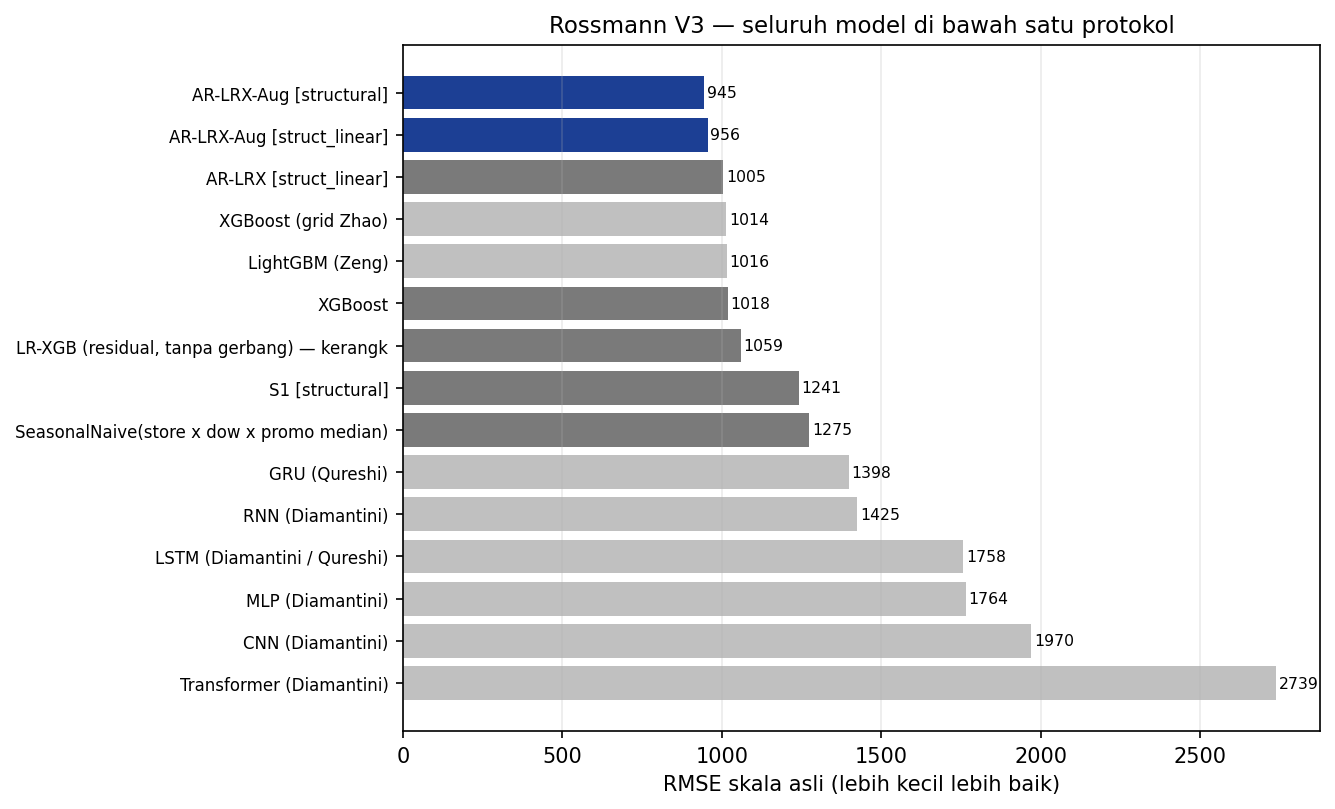

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)
t = table.sort_values("RMSE")
warna = ["#1c3f94" if a.startswith("exp05d") else
         ("#7a7a7a" if a.startswith("exp05b") else "#c0c0c0") for a in t.asal]
ax.barh(range(len(t)), t.RMSE, color=warna)
ax.set_yticks(range(len(t)))
ax.set_yticklabels([m[:42] for m in t.model], fontsize=8)
ax.invert_yaxis(); ax.set_xlabel("RMSE skala asli (lebih kecil lebih baik)")
ax.set_title("Rossmann V3 — seluruh model di bawah satu protokol", fontsize=11)
ax.grid(axis="x", alpha=.25)
for i, v in enumerate(t.RMSE):
    ax.text(v + 8, i, f"{v:.0f}", va="center", fontsize=7.5)
plt.tight_layout(); plt.show()

## 8. Cara melaporkan

* **Tabel bagian 5 menggantikan Tabel 3 naskah lama.** Semua baris kini berasal dari
  satu protokol, sehingga peringkatnya berarti.
* **Tabel bagian 6 adalah pembelaan metodologis Anda.** Ia menunjukkan bahwa angka
  rujukan lama pun menggelembung, bukan hanya angka Anda. Bila baseline memburuk
  dengan proporsi sebanding, itu bukti langsung bahwa perbandingan lama tidak sah —
  dan sekaligus menjelaskan mengapa 577,63 tidak boleh dipakai lagi.
* **Laporkan baseline yang masih unggul, bila ada.** Bila CNN atau MLP tetap
  mengungguli AR-LRX-Aug setelah protokolnya diadilkan, katakan demikian dan
  arahkan klaim ke sumbangan metodologis yang sudah kokoh: kapan dan mengapa
  hibridisasi residual bekerja (exp05b/exp05d), bukan klaim akurasi tertinggi.
* **Sebutkan keterbatasan determinisme.** Model neural di CPU tidak selalu identik
  bit-per-bit antar-jalan walaupun seed disetel; seluruh model pohon dan AR-LRX
  sudah diverifikasi identik.